In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv(r"C:\Users\chauh\Downloads\airline-passenger-traffic.csv", header=None)
print(data)

           0      1
0    1949-01  112.0
1    1949-02  118.0
2    1949-03  132.0
3    1949-04  129.0
4    1949-05  121.0
..       ...    ...
139  1960-08  606.0
140  1960-09  508.0
141  1960-10  461.0
142  1960-11  390.0
143  1960-12  432.0

[144 rows x 2 columns]


In [4]:
data.columns = ['Month', 'Passengers']
data['Month'] = pd.to_datetime(data['Month'], format = "%Y-%m")
data = data.set_index('Month')
data.head(12)

,Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0
1949-06-01,135.0
1949-07-01,148.0
1949-08-01,148.0
1949-09-01,136.0


# Time Series Analysis

### Plot time series data

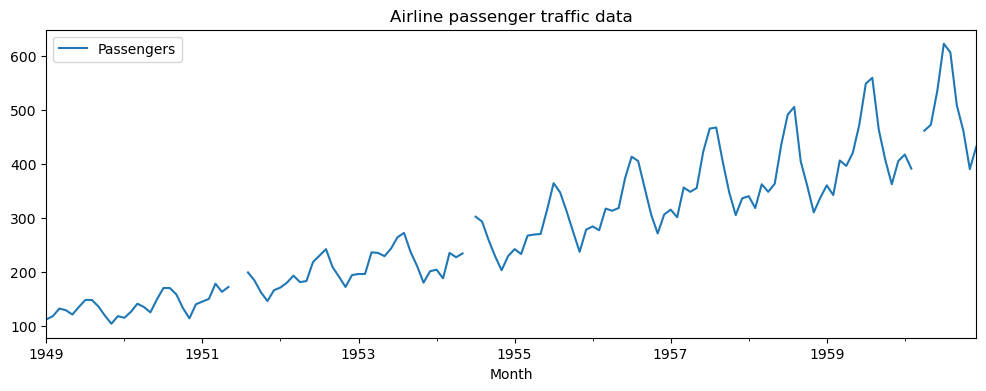

In [5]:
data.plot(figsize=(12,4))
plt.legend(loc='best')
plt.title('Airline passenger traffic data')
plt.show(block=False)

# Missing value treatment

### Mean imputation

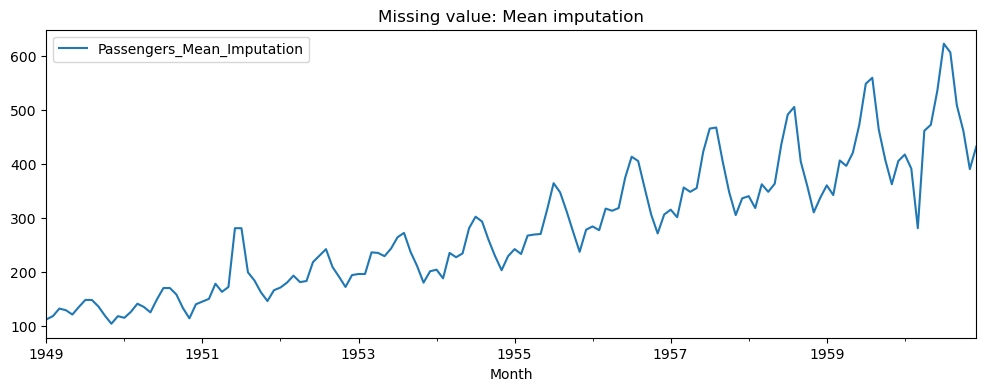

In [6]:
data = data.assign(Passengers_Mean_Imputation = data.Passengers.fillna(data.Passengers.mean()))
data[['Passengers_Mean_Imputation']].plot(figsize=(12,4))
plt.legend(loc='best')
plt.title("Missing value: Mean imputation")
plt.show(block=False)

## Linear Interpolation

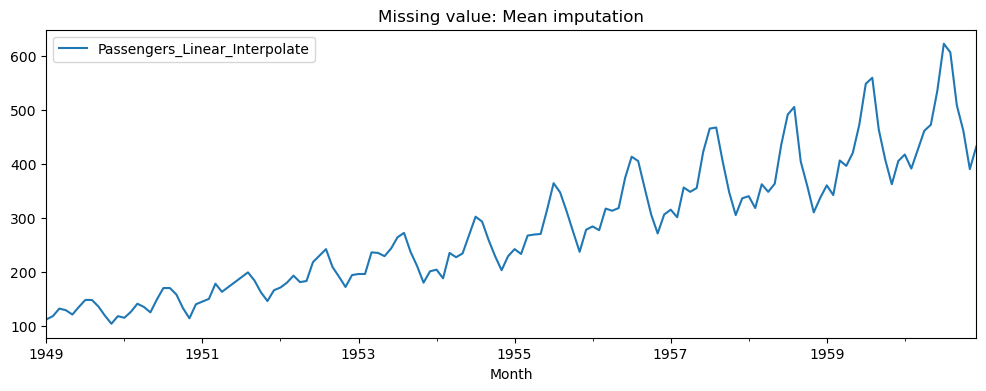

In [7]:
data = data.assign(Passengers_Linear_Interpolate = data.Passengers.interpolate(method='linear'))
data[['Passengers_Linear_Interpolate']].plot(figsize=(12,4))
plt.legend(loc='best')
plt.title("Missing value: Mean imputation")
plt.show(block=False)

#### Use linear interpolation to impute missing value

In [8]:
data['Passengers'] = data["Passengers_Linear_Interpolate"]

In [9]:
data

,Passengers,Passengers_Mean_Imputation,Passengers_Linear_Interpolate
Month,,,
1949-01-01,112.0,112.0,112.0
1949-02-01,118.0,118.0,118.0
1949-03-01,132.0,132.0,132.0
1949-04-01,129.0,129.0,129.0
1949-05-01,121.0,121.0,121.0
...,...,...,...
1960-08-01,606.0,606.0,606.0
1960-09-01,508.0,508.0,508.0
1960-10-01,461.0,461.0,461.0


## Outlier Detection

### Boxplot and Interquartile range

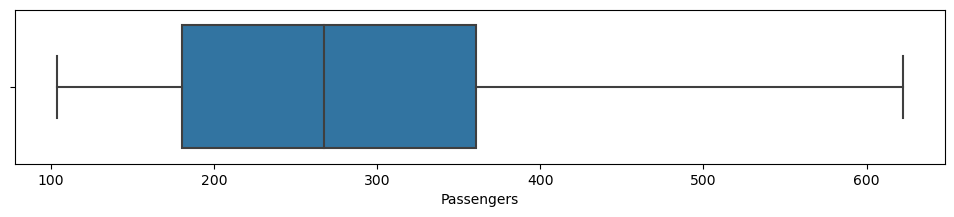

In [10]:
import seaborn as sns
fig = plt.subplots(figsize=(12,2))
ax = sns.boxplot(x=data['Passengers'], whis=1.5)

### Histogram

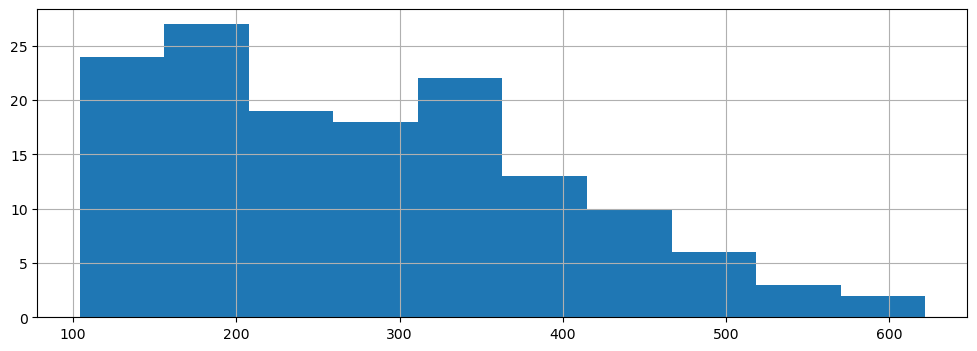

In [11]:
fig = data.Passengers.hist(figsize=(12,4))

#### No outliers detected in this time series data

## Time Series decomposition

#### Additive seasonal decomposition

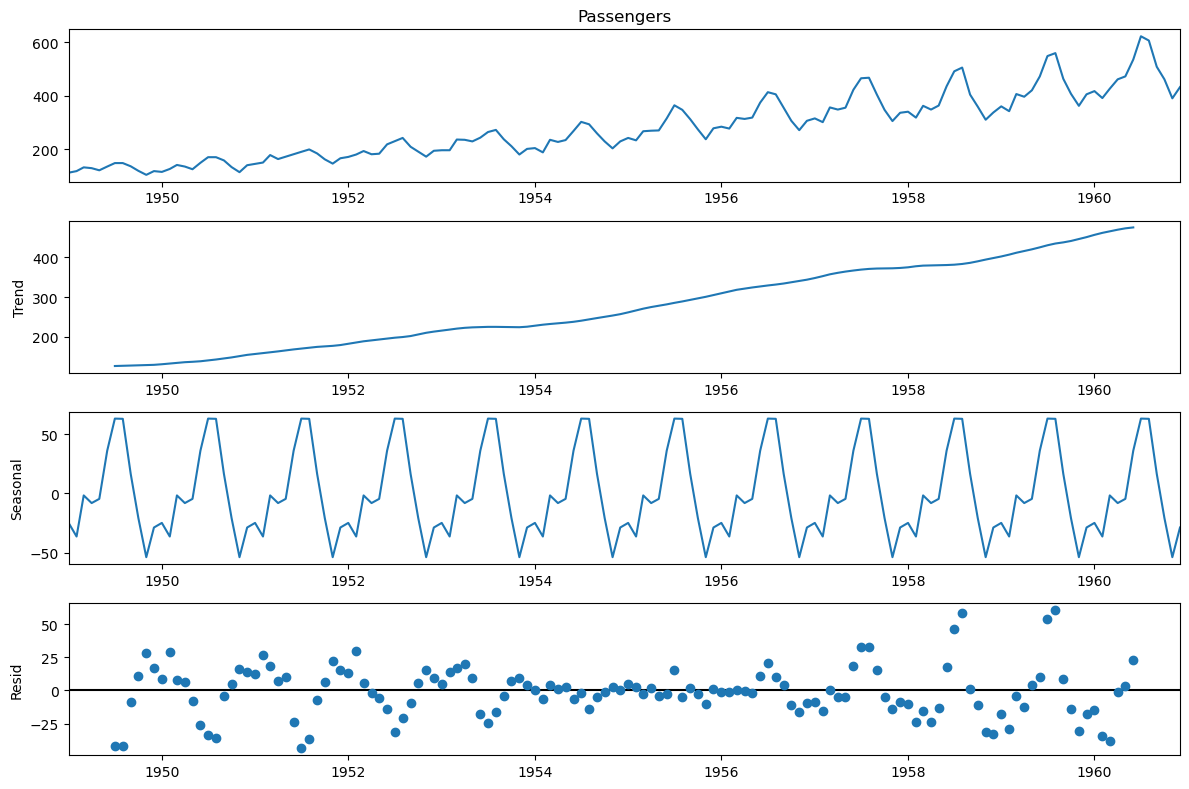

In [13]:
from pylab import rcParams
import statsmodels.api as sm
rcParams['figure.figsize'] = 12,8
decomposition = sm.tsa.seasonal_decompose(data.Passengers, model='additive')
fig = decomposition.plot()
plt.show()

## Multiplicative seasonal decomposition

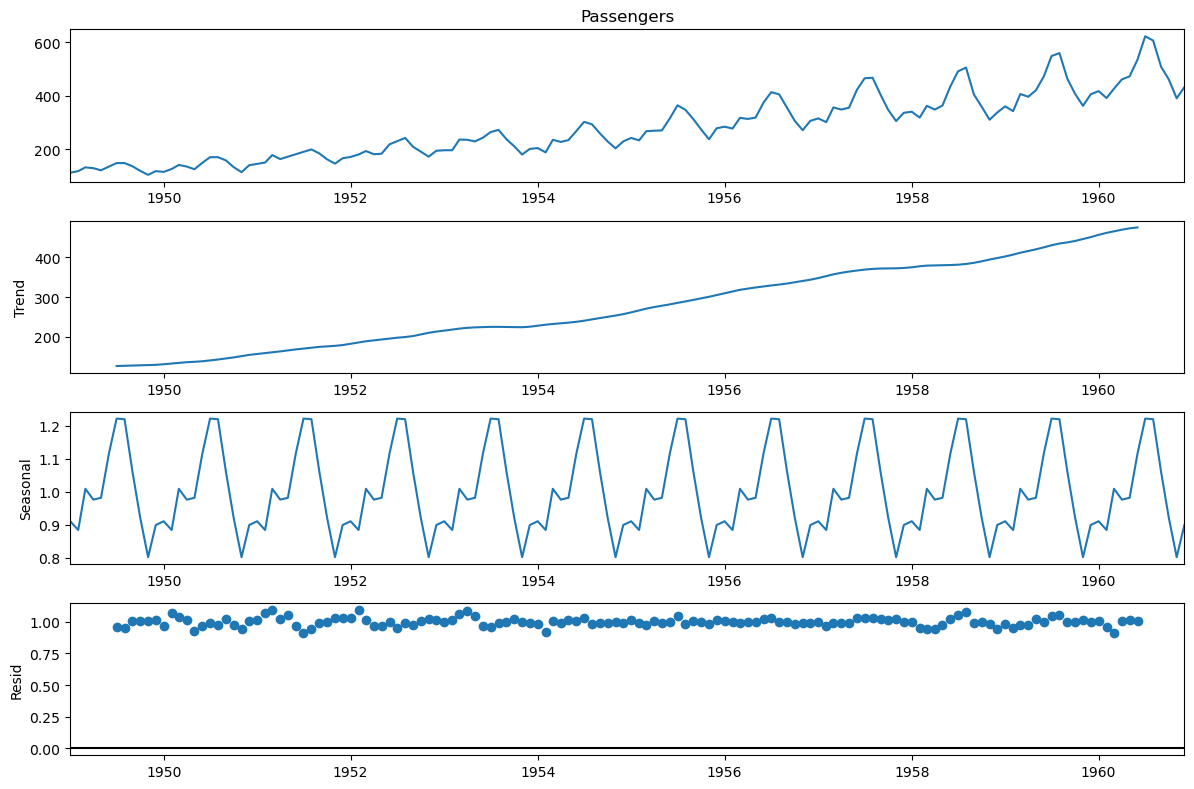

In [15]:
decomposition = sm.tsa.seasonal_decompose(data.Passengers, model = 'multiplicative')
fig = decomposition.plot()
plt.show()

# Build and Evaluate time series forecast

## splitting time series into Training and Test sets

In [16]:
train_len = 120
train = data[0:train_len]
test = data[train_len:]

## Naive method

In [17]:
y_hat_naive = test.copy()
y_hat_naive['naive_forecast'] = train['Passengers'][train_len-1]

### Plot Train, Test and Forecast

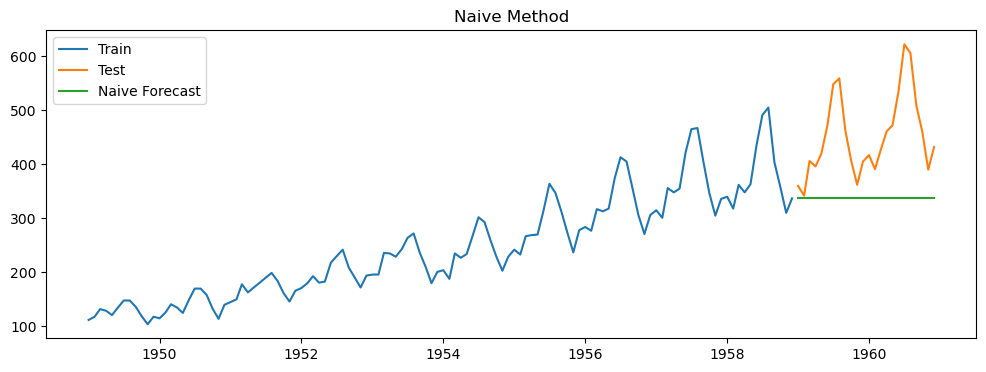

In [20]:
plt.figure(figsize=(12,4))
plt.plot(train['Passengers'], label='Train')
plt.plot(test['Passengers'], label='Test')
plt.plot(y_hat_naive['naive_forecast'], label='Naive Forecast')
plt.legend(loc='best')
plt.title('Naive Method')
plt.show()